In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV, LassoCV, LinearRegression
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Load Train and Test Data

In [3]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

train.head()

,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
0,0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11
1,1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11
2,2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6
3,3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10
4,4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9


In [4]:
train.info()
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 90615 entries, 0 to 90614
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              90615 non-null  int64  
 1   Sex             90615 non-null  str    
 2   Length          90615 non-null  float64
 3   Diameter        90615 non-null  float64
 4   Height          90615 non-null  float64
 5   Whole weight    90615 non-null  float64
 6   Whole weight.1  90615 non-null  float64
 7   Whole weight.2  90615 non-null  float64
 8   Shell weight    90615 non-null  float64
 9   Rings           90615 non-null  int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 6.9 MB
<class 'pandas.DataFrame'>
RangeIndex: 60411 entries, 0 to 60410
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              60411 non-null  int64  
 1   Sex             60411 non-null  str    
 2   Length          60411 

In [5]:
#repare X and y
y = train["Rings"]

X = train.drop(columns=["Rings", "id"])
X_test = test.drop(columns=["id"])

# Convert categorical variable Sex into dummy variables
X = pd.get_dummies(X, columns=["Sex"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=["Sex"], drop_first=True)

# Align columns
X_test = X_test.reindex(columns=X.columns, fill_value=0)

X.head()

,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Sex_I,Sex_M
0,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,False,False
1,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,False,False
2,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,True,False
3,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,False,True
4,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,True,False


In [7]:
#Train / Validation Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=42)

Model 1: Regularization Model Using Lasso

In [8]:
#Lasso
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=5, random_state=42, max_iter=10000))
])

lasso_pipeline.fit(X_train, y_train)

lasso_pred = lasso_pipeline.predict(X_val)

lasso_mae = mean_absolute_error(y_val, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_val, lasso_pred))
lasso_r2 = r2_score(y_val, lasso_pred)

print("Lasso MAE:", lasso_mae)
print("Lasso RMSE:", lasso_rmse)
print("Lasso R²:", lasso_r2)
print("Best Alpha:", lasso_pipeline.named_steps["lasso"].alpha_)

Lasso MAE: 1.392556692587367
Lasso RMSE: 2.024768512895664
Lasso R²: 0.6009009475121145
Best Alpha: 0.0022063763304642795


In [9]:
#Lasso Coefficients
lasso_coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso_pipeline.named_steps["lasso"].coef_
}).sort_values(by="Coefficient", ascending=False)

lasso_coef

,Feature,Coefficient
6,Shell weight,2.778902
3,Whole weight,1.489079
2,Height,0.753473
1,Diameter,0.572922
0,Length,-0.004216
8,Sex_M,-0.006242
7,Sex_I,-0.340432
5,Whole weight.2,-0.604988
4,Whole weight.1,-3.140700


In [10]:
#Selected Variables from Lasso
selected_features = lasso_coef[lasso_coef["Coefficient"] != 0]["Feature"].tolist()

selected_features

['Shell weight',
 'Whole weight',
 'Height',
 'Diameter',
 'Length',
 'Sex_M',
 'Sex_I',
 'Whole weight.2',
 'Whole weight.1']

In [11]:
#subset
X_train_subset = X_train[selected_features]
X_val_subset = X_val[selected_features]

subset_model = LinearRegression()
subset_model.fit(X_train_subset, y_train)

subset_pred = subset_model.predict(X_val_subset)

subset_mae = mean_absolute_error(y_val, subset_pred)
subset_rmse = np.sqrt(mean_squared_error(y_val, subset_pred))
subset_r2 = r2_score(y_val, subset_pred)

print("Subset Model MAE:", subset_mae)
print("Subset Model RMSE:", subset_rmse)
print("Subset Model R²:", subset_r2)

Subset Model MAE: 1.393015084792756
Subset Model RMSE: 2.023690349601808
Subset Model R²: 0.6013258646157316


Model 2: Principal Components Regression

In [12]:
#pcr
pcr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("linear", LinearRegression())
])

In [13]:
#Choose Best Number of Components
param_grid = {
    "pca__n_components": list(range(1, X_train.shape[1] + 1))
}

pcr_grid = GridSearchCV(
    pcr_pipeline,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

pcr_grid.fit(X_train, y_train)

print("Best number of components:", pcr_grid.best_params_)
print("Best CV RMSE:", -pcr_grid.best_score_)

Best number of components: {'pca__n_components': 9}
Best CV RMSE: 1.9882105655414093


In [14]:
#Evaluate PCR on Validation Data
best_pcr = pcr_grid.best_estimator_

pcr_pred = best_pcr.predict(X_val)

pcr_mae = mean_absolute_error(y_val, pcr_pred)
pcr_rmse = np.sqrt(mean_squared_error(y_val, pcr_pred))
pcr_r2 = r2_score(y_val, pcr_pred)

print("PCR MAE:", pcr_mae)
print("PCR RMSE:", pcr_rmse)
print("PCR R²:", pcr_r2)

PCR MAE: 1.3930150847927556
PCR RMSE: 2.023690349601808
PCR R²: 0.6013258646157316


In [15]:
#Compare Models
comparison = pd.DataFrame({
    "Model": ["Lasso", "Lasso-Informed Subset", "PCR"],
    "MAE": [lasso_mae, subset_mae, pcr_mae],
    "RMSE": [lasso_rmse, subset_rmse, pcr_rmse],
    "R²": [lasso_r2, subset_r2, pcr_r2]
})

comparison

,Model,MAE,RMSE,R²
0,Lasso,1.392557,2.024769,0.600901
1,Lasso-Informed Subset,1.393015,2.023690,0.601326
2,PCR,1.393015,2.023690,0.601326


Assumption Checks
Use the best linear-style model, usually the Lasso-informed subset model or PCR.

In [16]:
#check residuals for the subset model
residuals = y_val - subset_pred

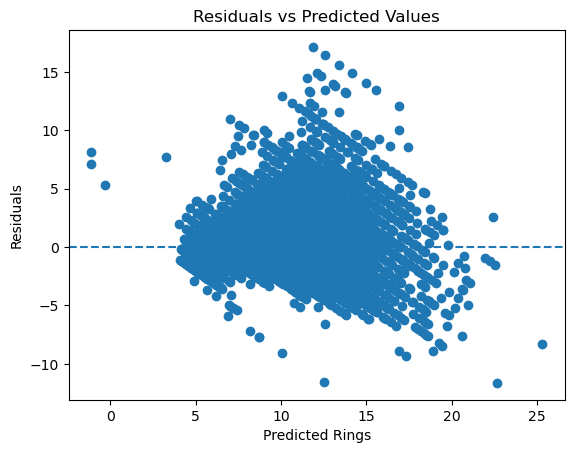

In [17]:
#Linearity and Homoscedasticity
plt.scatter(subset_pred, residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Rings")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()

If residuals are randomly scattered around zero, the linearity assumption is reasonable. If the spread increases or decreases, there may be heteroscedasticity.

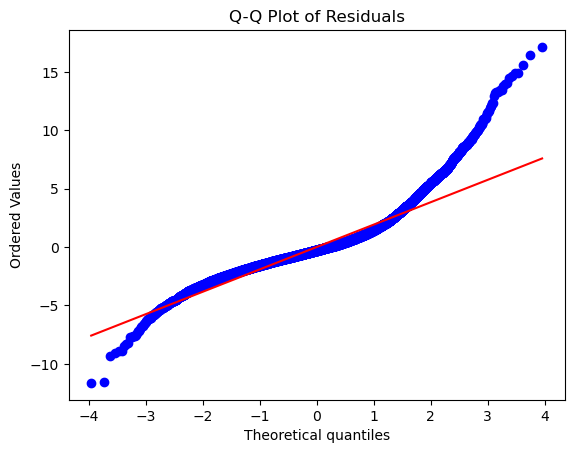

In [18]:
#Normality of Residuals
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

If points follow the diagonal line, residuals are approximately normal. Deviations at the tails suggest some non-normality.

In [19]:
#Multicollinearity Check
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X_vif = X[selected_features].astype(float)
X_vif = sm.add_constant(X_vif)

vif_table = pd.DataFrame()
vif_table["Feature"] = X_vif.columns
vif_table["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_table

,Feature,VIF
0,const,84.084459
1,Shell weight,18.339175
2,Whole weight,69.242348
3,Height,7.813579
4,Diameter,54.291324
5,Length,51.208712
6,Sex_M,1.442002
7,Sex_I,2.387746
8,Whole weight.2,20.067845
9,Whole weight.1,21.463228


VIF values above 5 suggest moderate multicollinearity, while values above 10 suggest serious multicollinearity. PCR helps address this issue by transforming correlated predictors into independent principal components.

In [20]:
final_model = lasso_pipeline

final_predictions = final_model.predict(X_test)

submission = pd.DataFrame({
    "id": test["id"],
    "Rings": final_predictions
})

submission.head()

,id,Rings
0,90615,8.684061
1,90616,10.033314
2,90617,10.347413
3,90618,10.838459
4,90619,7.750773


In [21]:
submission.to_csv("abalone_lasso_submission.csv", index=False)

In [22]:
final_model = best_pcr

final_predictions = final_model.predict(X_test)

submission = pd.DataFrame({
    "id": test["id"],
    "Rings": final_predictions
})

submission.to_csv("abalone_pcr_submission.csv", index=False)

Interpetation:

A regularized regression model was developed using lasso regression to predict Rings in the Abalone dataset. Lasso was selected because it applies a penalty to regression coefficients and can shrink less useful predictors toward zero. This helped identify the most important predictors and informed a smaller best subset model. The lasso-informed subset model was then compared against the full regularized model using MAE, RMSE, and R².

A principal components regression model was also developed using standardized predictors and principal component analysis. PCR reduces dimensionality by transforming the original predictors into uncorrelated components. Cross-validation was used to determine the optimal number of principal components. This approach was useful because several physical measurements in the Abalone dataset may be correlated, which can affect ordinary regression coefficient stability.

Model assumptions were investigated using residual plots, Q-Q plots, and VIF values. The residual plot was used to evaluate linearity and constant variance, while the Q-Q plot assessed whether residuals were approximately normally distributed. VIF values were used to examine multicollinearity among predictors. Overall, the models provided useful predictive performance, with regularization and PCR offering different advantages. Lasso improved interpretability through variable selection, while PCR helped address multicollinearity by using uncorrelated principal components.